In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
DATA_PATH = Path("../data/raw/Crop_recommendation.csv")

In [4]:
df = pd.read_csv(DATA_PATH)

In [5]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
df.shape

(2200, 8)

The dataset contains 2,200 observations and 8 columns. There are 7 predictor variables and 1 target variable.

In [7]:
df.columns.tolist()

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


All predictor variables are numeric, while the target variable is categorical. This means the dataset is immediately suitable for standard machine learning classification models after separating features and target.

In [9]:
df.isna().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

There are no missing values in the dataset. Therefore, no imputation is required at this stage.

In [10]:
df.duplicated().sum()

np.int64(0)

There are no duplicated rows in the dataset.

In [11]:
df["label"].nunique()

22

In [12]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

The target variable contains 22 crop classes. each crop class has exactly 100 observations, making the dataset perfectly balanced. this is good for model training because no class rebalancing is required.

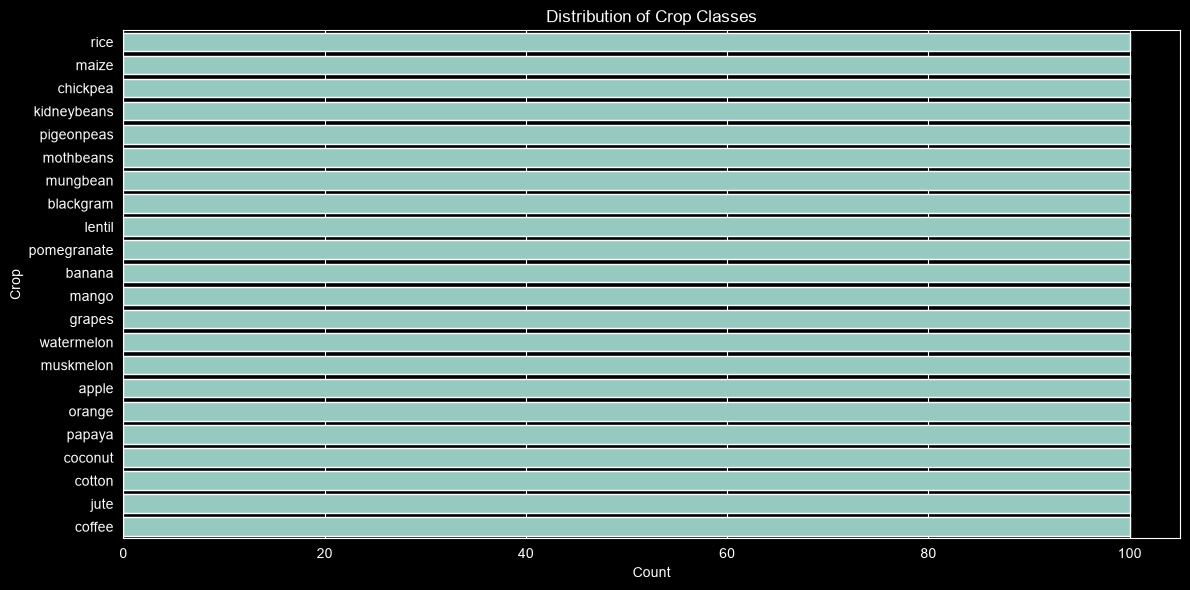

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="label",
    order=df["label"].value_counts().index
)
plt.title("Distribution of Crop Classes")
plt.xlabel("Count")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

The plot confirms that all crop classes are equally represented. This reduces the risk of the model being biased toward majority classes.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


The numerical features show different scales. For example, rainfall ranges up to almost 300, while pH ranges from about 3.5 to 9.9. Scale-sensitive models such as Logistic Regression, KNN, and SVM will require feature scaling.

In [15]:
numeric_features = df.drop(columns="label").columns.tolist()
target = "label"

numeric_features

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

In [17]:
feature_range = df[numeric_features].agg(["min", "max", "mean", "median", "std"])
feature_range

,N,P,K,temperature,humidity,ph,rainfall
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
median,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
